# This notebook is about EDA on Fantasy Premier League Points



### First Part of Notebook

* Main features and data 
* Main Sources of Data ( FPL and teams )
* Get the top performers of the 2019-2020 campaign 

### I. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

### II. Functions for EDA

In [2]:
def top_statistics(datadf, key, n):
    """get the n largest rows for a specific variable in dataframe """
    return datadf.nlargest(n, key)

In [3]:
def plot_fpl_features_bar(datadf, featureslist):
    """return a plot of the features against the player names"""
    for i in range(len(featureslist)):
        fig = plt.figure()
        locals()["x" + str(i+1)] = fig.add_subplot(int(str(22) + str(i+1)))
        #Random generate a color
        #data_df = datadf.set_index('name').sort_values(by=str(featureslist[i]))
    for i in range(len(featureslist)):
        data_df = datadf.set_index('name').sort_values(by=str(featureslist[i]))
        print(["x" + str(i+1)])
        return data_df.plot.barh(y=str(featureslist[i]),ax=locals()["x" + str(i+1)],figsize=(15,10), color='red')

### III. Data Import

In [29]:
# FPL data from 2019-2020
FPL_data_1920 = pd.read_csv('../Data/2020-07-31_fpl_players.csv')
# FPL Data at the start of the 20-21
FPL_data = pd.read_csv('../Data/2020-08-26_fpl_players.csv')
#FPL_data as of the 09/09 
FPL_data = pd.read_csv('../Data/2020-09-09_fpl_players.csv')
# Teams information
teams_data = pd.read_csv('../Data/teams.csv', index_col=False)

In [1088]:
ProfileReport(FPL_data_1920)

Number of variables,53
Number of observations,666
Total Missing (%),4.0%
Total size in memory,266.7 KiB
Average record size in memory,410.1 B
Numeric,27
Categorical,6
Boolean,2
Date,0
Text (Unique),1
Rejected,17


## Features

In [9]:
football_str = ['web_name', 'first_name', 'second_name', 'team', 'team_code', 'element_type']
football_stats = ['assists', 'clean_sheets', 'goals_conceded', 'goals_scored', 'minutes', 
                  'own_goals', 'penalties_missed', 'penalties_saved','red_cards', 'saves',
                  'yellow_cards']
football_fpl_price = ['cost_change_event', 'cost_change_event_fall', 'cost_change_start','now_cost']
features_fpl = ['bonus', 'bps', 'form','ep_next', 'ep_this', 'event_points','ict_index',
                'in_dreamteam','points_per_game', 'influence','threat','special', 'total_points',
                'value_form', 'value_season']
features_availability = ['chance_of_playing_next_round', 'chance_of_playing_this_round',
                         'selected_by_percent', 'transfers_in','transfers_in_event', 
                         'transfers_out', 'transfers_out_event']
football_news = ['news', 'news_added']

## III. Team Analysis

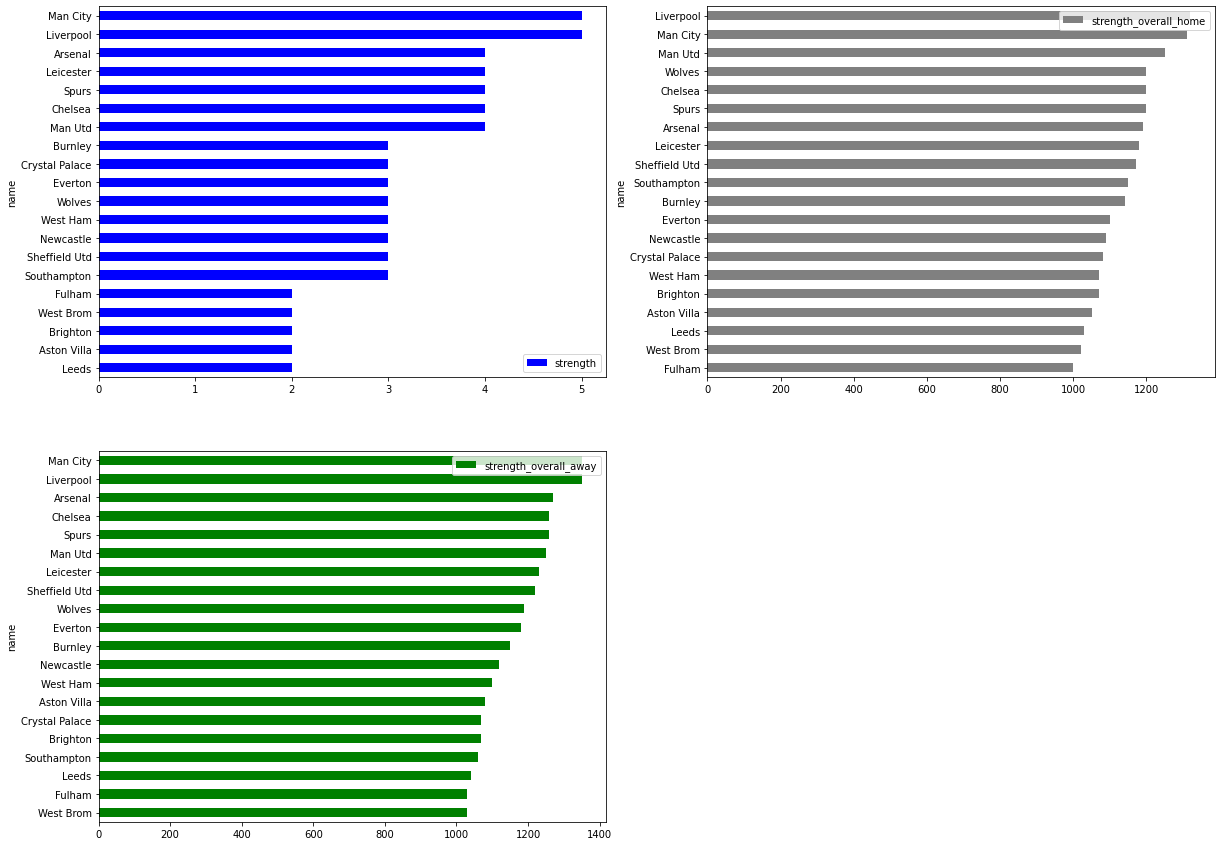

In [7]:
fig = plt.figure()

# Divide the figure into a 2x2 grid, and give me the first section
ax1 = fig.add_subplot(221)
# Divide the figure into a 2x2 grid, and give me the second section
ax2 = fig.add_subplot(222)
# Divide the figure into a 2x2 grid, and give me the third section
ax3 = fig.add_subplot(223)
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2)
teams_data.set_index('name').sort_values(by='strength').plot.barh(y='strength',ax=ax1,figsize=(20,15), color='blue');
teams_data.set_index('name').sort_values(by='strength_overall_home').plot.barh(y='strength_overall_home',ax=ax2, color='grey');
teams_data.set_index('name').sort_values(by='strength_overall_away').plot.barh(y='strength_overall_away', ax=ax3, color='green');

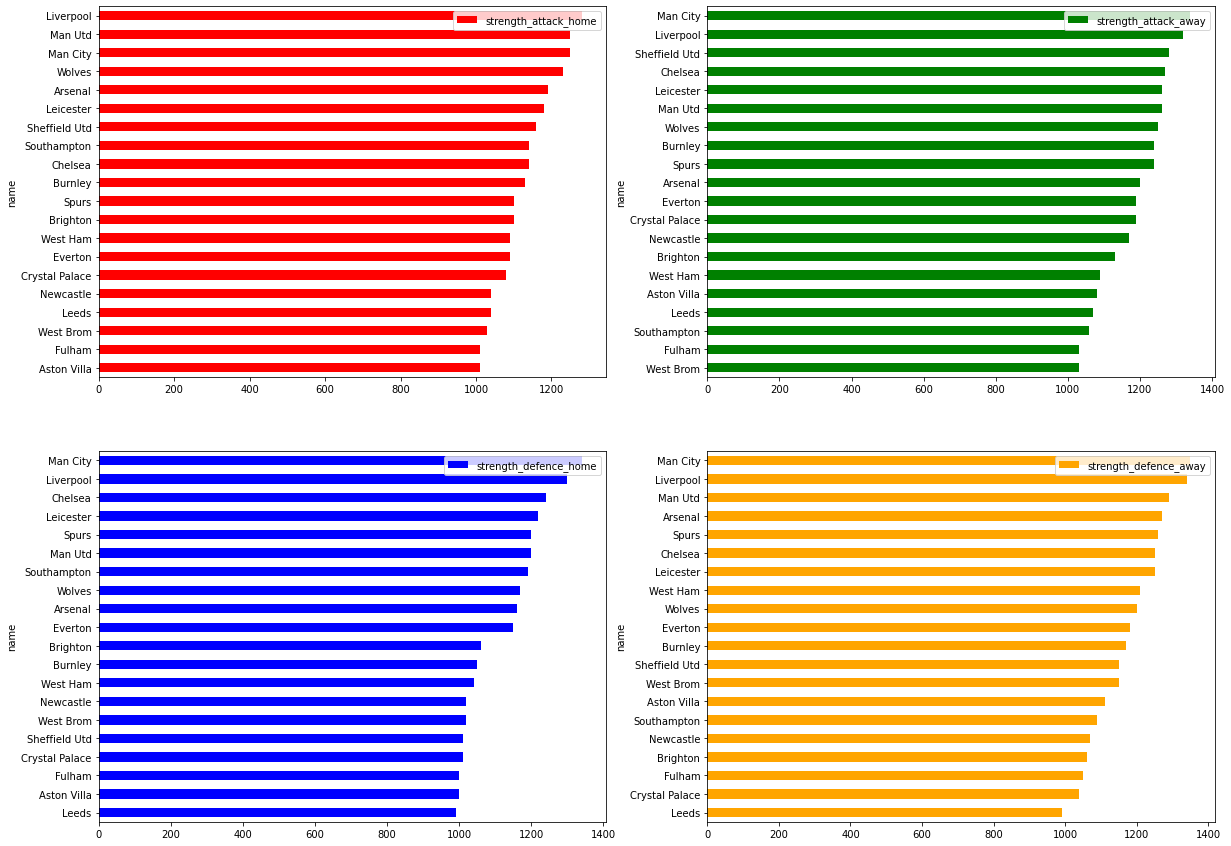

In [8]:
fig = plt.figure()
# Divide the figure into a 2x2 grid, and give me the first section
ax1 = fig.add_subplot(221)
# Divide the figure into a 2x2 grid, and give me the second section
ax2 = fig.add_subplot(222)
# Divide the figure into a 2x2 grid, and give me the third section
ax3 = fig.add_subplot(223)
# Divide the figure into a 2x2 grid, and give me the third section
ax4 = fig.add_subplot(224)
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2)
teams_data.set_index('name').sort_values(by='strength_attack_home')\
    .plot.barh(y='strength_attack_home',ax=ax1,figsize=(20,15), color='red');
teams_data.set_index('name').sort_values(by='strength_attack_away')\
    .plot.barh(y='strength_attack_away',ax=ax2, color='green');
teams_data.set_index('name').sort_values(by='strength_defence_home')\
    .plot.barh(y='strength_defence_home', ax=ax3, color='blue');
teams_data.set_index('name').sort_values(by='strength_defence_away')\
    .plot.barh(y='strength_defence_away', ax=ax4, color='orange');

## IV. Players Analysis

### 1. Players Availabilty

In [28]:
#### 'chance_of_playing_next_round', 'chance_of_playing_this_round',

In [31]:
FPL_data['chance_of_playing_next_round'].value_counts(dropna=False)

NaN      442
0.0       47
75.0       9
100.0      5
50.0       5
25.0       3
Name: chance_of_playing_next_round, dtype: int64

In [34]:
FPL_data[FPL_data['chance_of_playing_next_round'].notna()][['first_name', 'web_name']]

,first_name,web_name
6,Shkodran,Mustafi
9,Pablo,Marí
12,Calum,Chambers
25,Gabriel Teodoro,Martinelli
30,Tom,Heaton
...,...,...
478,Jordan,Hugill
480,Albian,Ajeti
484,Issa,Diop
494,Jonathan,Jonny


In [23]:
def form_analysis(n):
    
    fig = plt.figure()
    # Divide the figure into a 2x2 grid, and give me the first section
    ax1 = fig.add_subplot(221)
    # Divide the figure into a 2x2 grid, and give me the second section
    ax2 = fig.add_subplot(222)
    # Divide the figure into a 2x2 grid, and give me the third section
    ax3 = fig.add_subplot(223)
    # Divide the figure into a 2x2 grid, and give me the third section
    #ax4 = fig.add_subplot(224)
    #data = FPL_data_1920\
     #   .nlargest(20, 'total_points')\
     #   [['web_name', 'total_points', 'assists', 'bonus', 'goals_scored']]\
     #   .set_index('web_name')\

    data = FPL_data_1920\
        [['web_name', 'form', 'value_season', 'value_form']]\
        .set_index('web_name')\
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2)
    data.sort_values(by='form',ascending=False)[:n].iloc[::-1].plot.barh(y='form',ax=ax1,figsize=(20,20), color=['red','orange']);
    for i, v in enumerate(data.sort_values(by='form',ascending=False)[:n].iloc[::-1]['form']):
        ax1.text(v + 0.05, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='value_season', ascending=False)[:n].iloc[::-1].plot.barh(y='value_season',ax=ax2, color=['green','yellow', 'grey']);
    for i, v in enumerate(data.sort_values(by='value_season',ascending=False)[:n].iloc[::-1]['value_season']):
        ax2.text(v + 0.3, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='value_form', ascending=False)[:n].iloc[::-1].plot.barh(y='value_form', ax=ax3, color=['blue','cyan','purple']);
    for i, v in enumerate(data.sort_values(by='value_form',ascending=False)[:n].iloc[::-1]['value_form']):
        ax3.text(v + 0.05 , i , str(v), color='black', fontweight='bold')
    #data.sort_values(by='goals_scored', ascending=False)[:n].iloc[::-1].plot.barh(y='goals_scored', ax=ax4, color=['green', 'brown', 'magenta']);
    #for i, v in enumerate(data.sort_values(by='goals_scored',ascending=False)[:n].iloc[::-1]['goals_scored']):
        #ax4.text(v + 0.3, i, str(v), color='black', fontweight='bold')

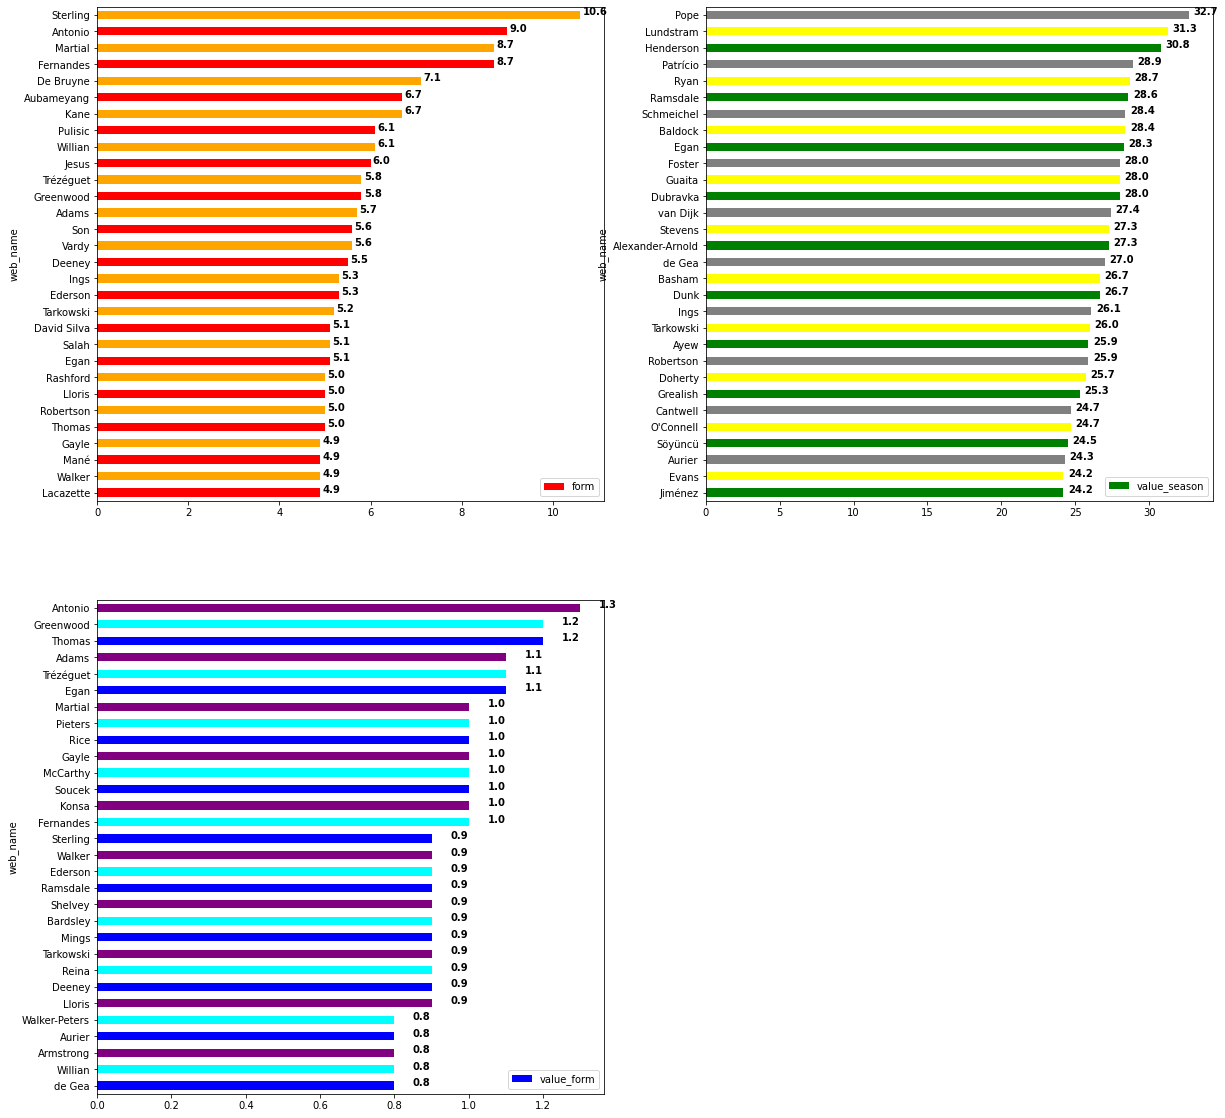

In [25]:
form_analysis(30)

In [10]:
def points_analysis(n):
    
    fig = plt.figure()
    # Divide the figure into a 2x2 grid, and give me the first section
    ax1 = fig.add_subplot(221)
    # Divide the figure into a 2x2 grid, and give me the second section
    ax2 = fig.add_subplot(222)
    # Divide the figure into a 2x2 grid, and give me the third section
    ax3 = fig.add_subplot(223)
    # Divide the figure into a 2x2 grid, and give me the third section
    ax4 = fig.add_subplot(224)
    #data = FPL_data_1920\
     #   .nlargest(20, 'total_points')\
     #   [['web_name', 'total_points', 'assists', 'bonus', 'goals_scored']]\
     #   .set_index('web_name')\

    data = FPL_data_1920\
        [['web_name', 'total_points', 'assists', 'bonus', 'goals_scored']]\
        .set_index('web_name')\
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2)
    data.sort_values(by='total_points',ascending=False)[:n].iloc[::-1].plot.barh(y='total_points',ax=ax1,figsize=(20,20), color=['red','orange']);
    for i, v in enumerate(data.sort_values(by='total_points',ascending=False)[:n].iloc[::-1]['total_points']):
        ax1.text(v + 1, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='assists', ascending=False)[:n].iloc[::-1].plot.barh(y='assists',ax=ax2, color=['green','yellow', 'grey']);
    for i, v in enumerate(data.sort_values(by='assists',ascending=False)[:n].iloc[::-1]['assists']):
        ax2.text(v + 0.3, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='bonus', ascending=False)[:n].iloc[::-1].plot.barh(y='bonus', ax=ax3, color=['blue','cyan','purple']);
    for i, v in enumerate(data.sort_values(by='bonus',ascending=False)[:n].iloc[::-1]['bonus']):
        ax3.text(v + 0.3, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='goals_scored', ascending=False)[:n].iloc[::-1].plot.barh(y='goals_scored', ax=ax4, color=['green', 'brown', 'magenta']);
    for i, v in enumerate(data.sort_values(by='goals_scored',ascending=False)[:n].iloc[::-1]['goals_scored']):
        ax4.text(v + 0.3, i, str(v), color='black', fontweight='bold')

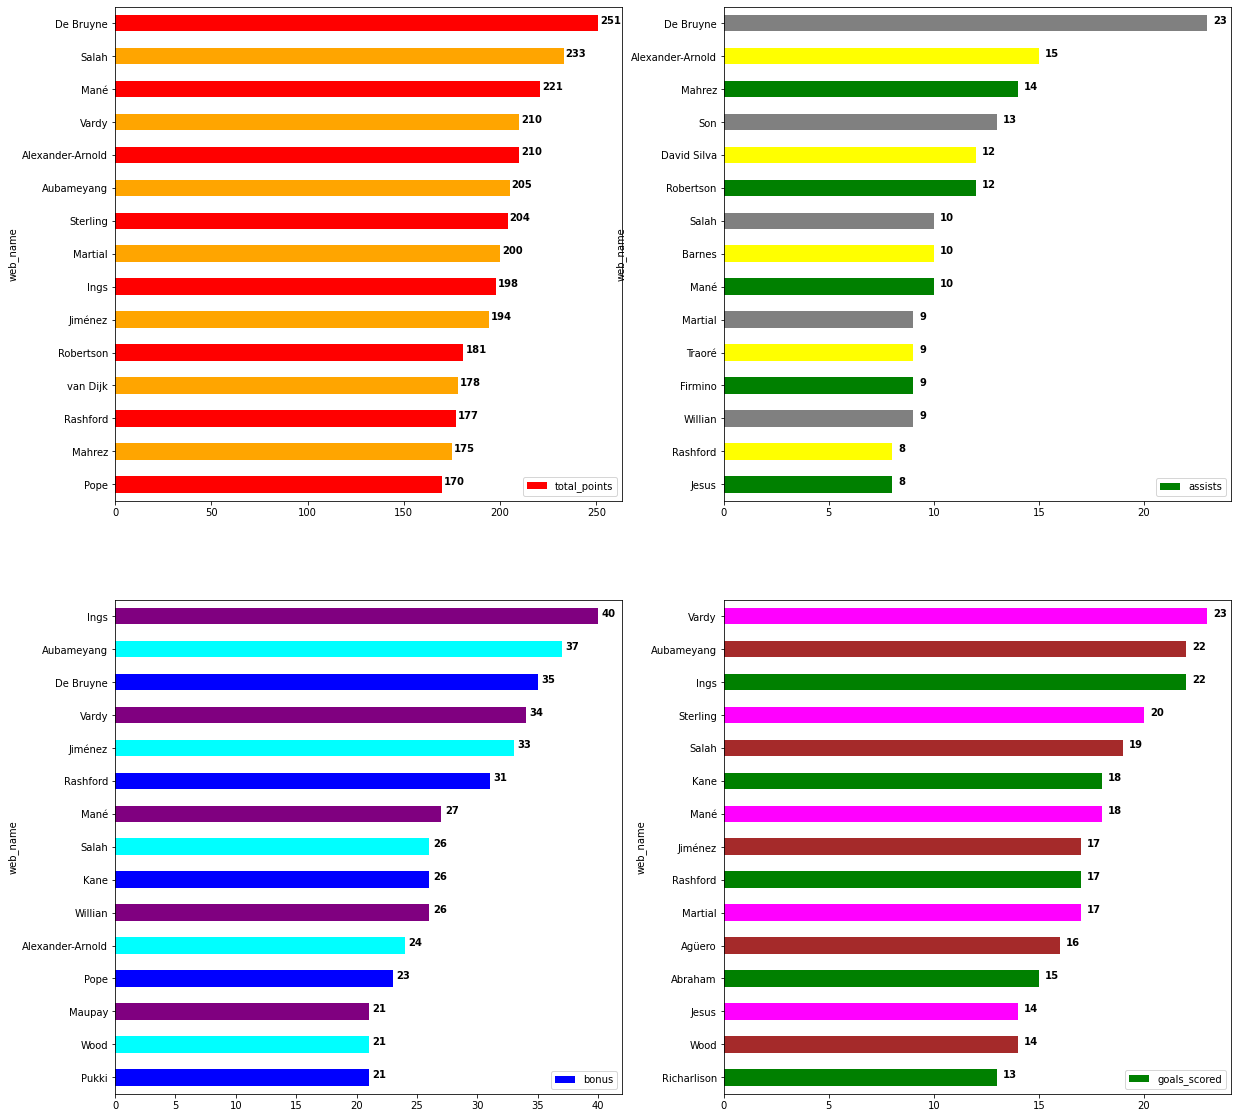

In [11]:
# Analysis of 15 top players on total points, assists, bonus, goals_scored
points_analysis(15)

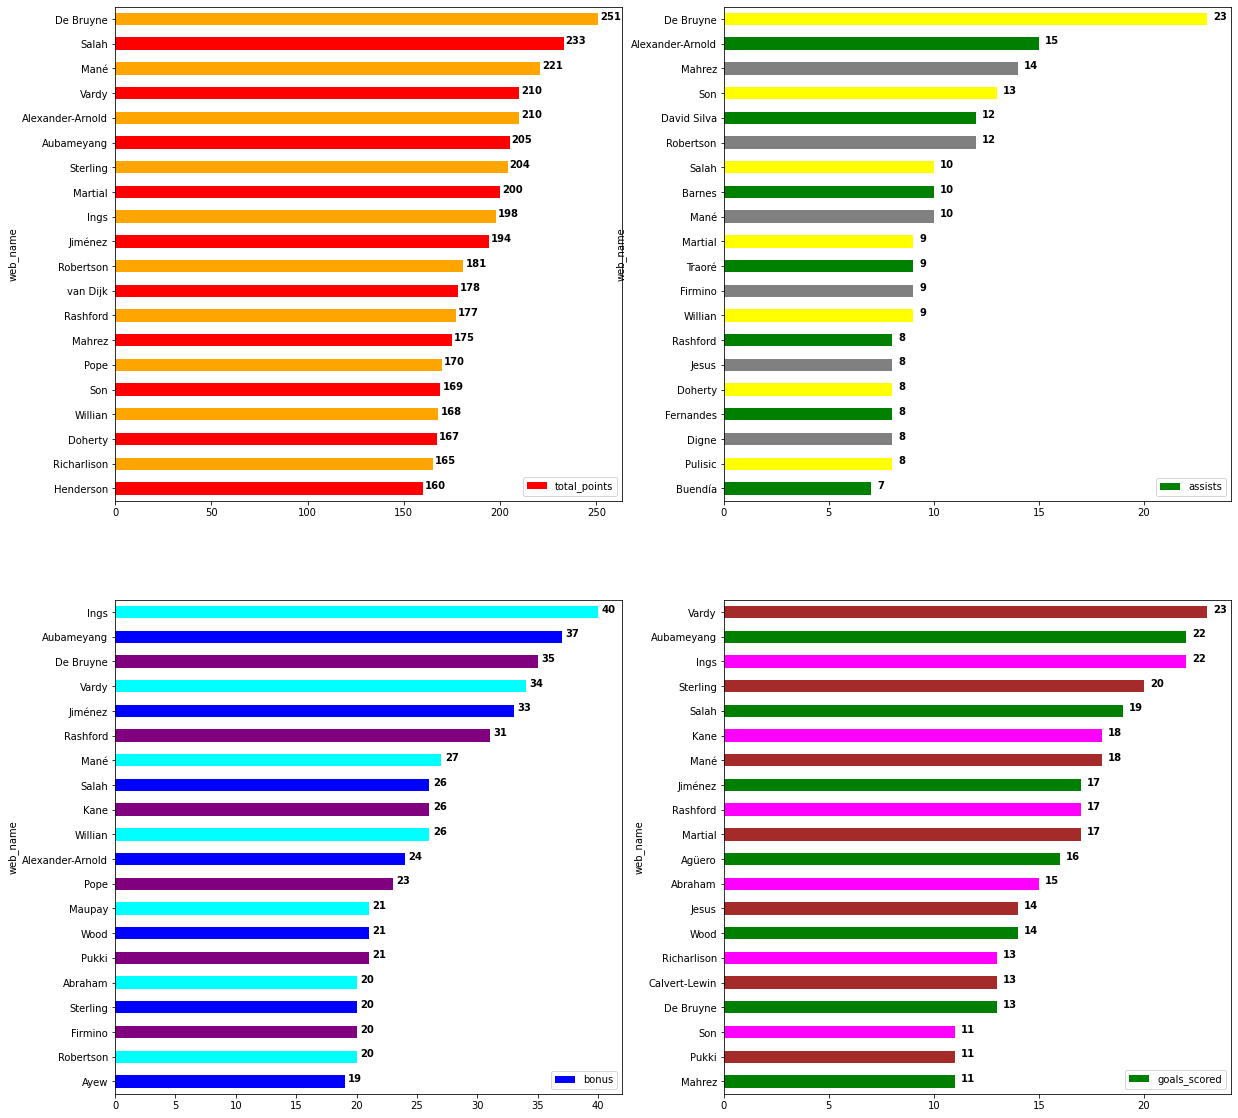

In [12]:
# Analysis of 30 top players on total points, assists, bonus, goals_scored
points_analysis(20)

In [203]:
def cost_analysis(n):
    
    fig = plt.figure()
    # Divide the figure into a 2x2 grid, and give me the first section
    ax1 = fig.add_subplot(221)
    # Divide the figure into a 2x2 grid, and give me the second section
    ax2 = fig.add_subplot(222)
    # Divide the figure into a 2x2 grid, and give me the third section
    ax3 = fig.add_subplot(223)
    ax4 = fig.add_subplot(224)
   #data = FPL_data_1920\
     #   .nlargest(20, 'total_points')\
     #   [['web_name', 'total_points', 'assists', 'bonus', 'goals_scored']]\
     #   .set_index('web_name')\

    data = FPL_data_1920\
        [['web_name', 'cost_change_start', 'now_cost']]\
        .set_index('web_name')\
#fig, (ax1, ax2, ax3, ax4) = plt.subplots(2, 2)
    data.sort_values(by='cost_change_start',ascending=False)[:n].plot.barh(y='cost_change_start',ax=ax1,figsize=(20,20), color=['red','orange']);
    for i, v in enumerate(data.sort_values(by='cost_change_start',ascending=False)[:n]['cost_change_start']):
        ax1.text(v + 1, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='cost_change_start', ascending=False)[-n:].plot.barh(y='cost_change_start',ax=ax2, color=['green','yellow', 'grey']);
    for i, v in enumerate(data.sort_values(by='cost_change_start',ascending=False)[-n:]['cost_change_start']):
        ax2.text(v + 0.3, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='now_cost', ascending=False)[:n].plot.barh(y='now_cost', ax=ax3, color=['blue','cyan','purple']);
    for i, v in enumerate(data.sort_values(by='now_cost',ascending=False)[:n]['now_cost']):
        ax3.text(v + 0.3, i , str(v), color='black', fontweight='bold')
    data.sort_values(by='now_cost', ascending=False)[-n:].plot.barh(y='now_cost', ax=ax4, color=['green', 'brown', 'magenta']);
    for i, v in enumerate(data.sort_values(by='now_cost',ascending=False)[-n:]['now_cost']):
        ax4.text(v + 0.3, i, str(v), color='black', fontweight='bold')

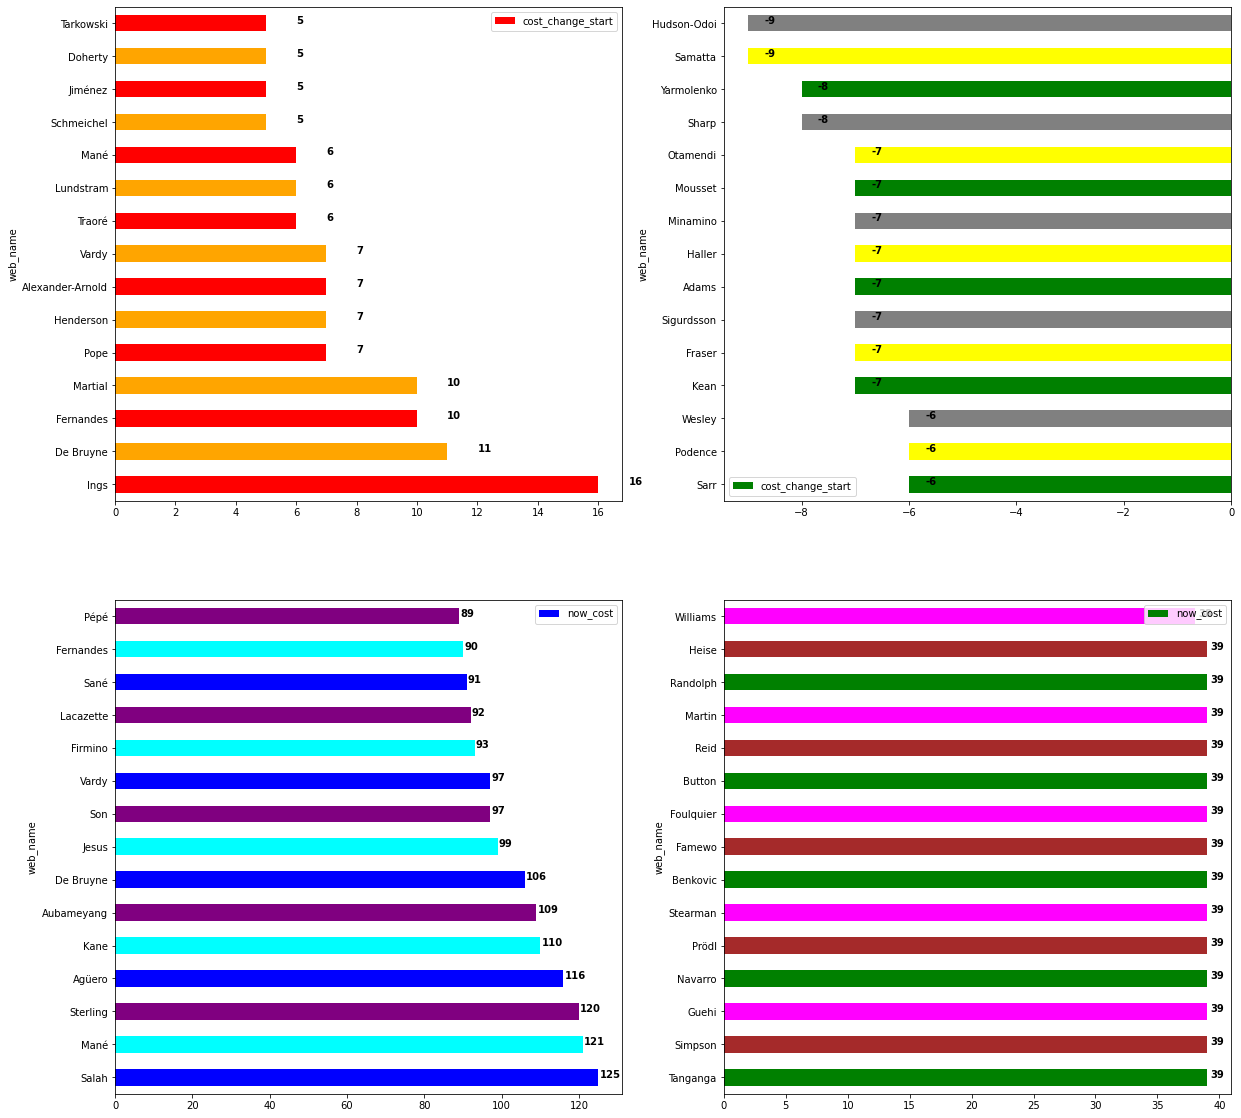

In [205]:
cost_analysis(15)

### IV. Merge the two dataframes

1. Merge 19/20 and 20/21 seasons
2. Merge 19/20 season with team information

In [219]:
FPL_diff_seasons = pd.merge(FPL_data, FPL_data_1920, how='left',
                            on=['code', 'web_name'], suffixes=('_20_21','_19_20'))

In [881]:
# Merge the two tables in Dataframes
full_data = pd.merge(FPL_data, teams_data, how='left',
                     left_on='team_code', right_on='code')

## Points Analysis

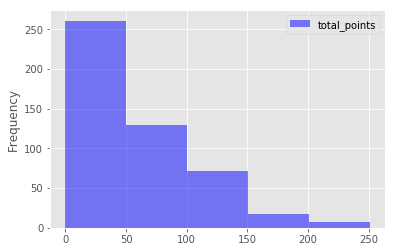

1:59: E231 missing whitespace after ','
1:72: E231 missing whitespace after ','
1:80: E501 line too long (83 > 79 characters)
1:83: E703 statement ends with a semicolon


In [1081]:
full_data.plot.hist(x='web_name', y='total_points', bins=5,color='blue',alpha=0.5);

## Minutes Analysis

In [26]:
FPL_data.minutes.describe()

count     488.000000
mean     1276.118852
std      1120.075193
min         0.000000
25%        86.000000
50%      1110.000000
75%      2234.250000
max      3420.000000
Name: minutes, dtype: float64

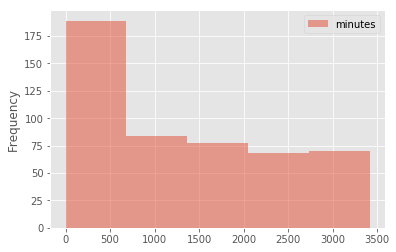

1:54: E231 missing whitespace after ','
1:65: E703 statement ends with a semicolon


In [1082]:
full_data.plot.hist(x='web_name', y='minutes', bins=5,alpha=0.5);

In [13]:
full_data[full_data['total_points']> 120].plot.hist(x='web_name', y='minutes', bins=5,alpha=0.5);

NameError: name 'full_data' is not defined

### 1. Analysis per team

#### A. Total Points 

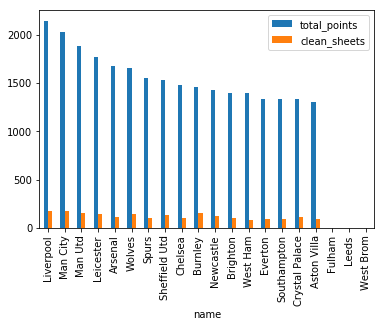

3:16: E703 statement ends with a semicolon


In [880]:
full_data.loc[:, ['total_points', 'clean_sheets', 'name']]\
    .groupby(['name']).sum().sort_values(by='total_points', ascending=False)\
    .plot.bar();

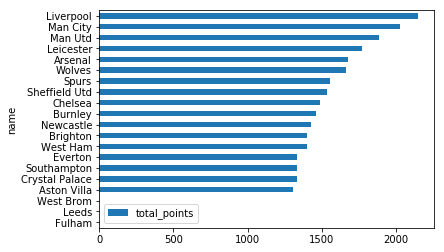

3:29: E703 statement ends with a semicolon


In [915]:
full_data.loc[:, ['total_points', 'name']]\
    .groupby(['name']).sum().sort_values(by='total_points', ascending=True)\
    .plot.barh(stacked=True);

#### B. Clean Sheets

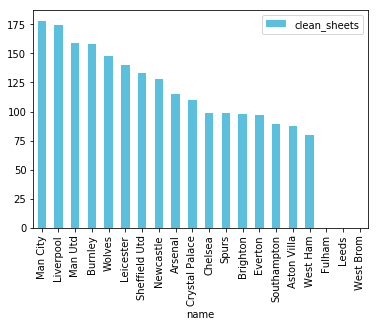

4:31: E703 statement ends with a semicolon


In [900]:
full_data.loc[:, ['clean_sheets', 'name']]\
    .groupby(['name'])\
    .sum().sort_values(by='clean_sheets', ascending=False)\
    .plot.bar(color='#5bc0de');

#### C. Points per game

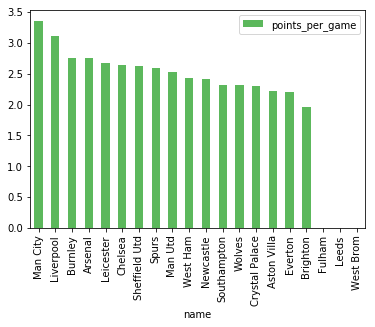

4:31: E703 statement ends with a semicolon


In [898]:
full_data.loc[:, ['points_per_game', 'name']]\
    .groupby(['name']).mean()\
    .sort_values(by='points_per_game', ascending=False)\
    .plot.bar(color='#5cb85c');

### 2. Analysis per position 

In [925]:
full_data.element_type.value_counts(dropna=False)

3    202
2    175
4     61
1     50
Name: element_type, dtype: int64

In [927]:
nombre_de_roues = {"voiture": 4, "vélo": 2, "tricycle": 3}

In [935]:
dict_position = {1: "GK", 2: "DF", 3: "MF", 4: "ST"}

In [939]:
full_data['position'] = full_data.element_type.map(dict_position)

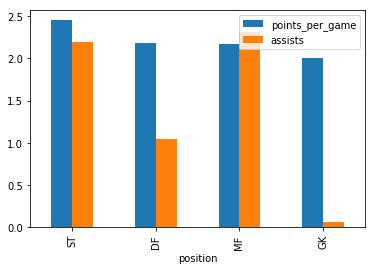

4:16: E703 statement ends with a semicolon


In [943]:
full_data.loc[:, ['points_per_game', 'assists', 'position']]\
    .groupby(['position']).mean()\
    .sort_values(by='points_per_game', ascending=False)\
    .plot.bar();

In [1049]:
full_data.loc[:, ['total_points', 'points_per_game', 'bonus',
                  'position', 'minutes']]\
    .groupby(['position']).mean()

,total_points,points_per_game,bonus,minutes
position,,,,
DF,50.045714,2.180571,3.708571,1333.228571
GK,49.620000,2.002000,3.700000,1207.560000
MF,56.480198,2.163861,4.188119,1267.009901
ST,67.000000,2.449180,7.639344,1198.639344


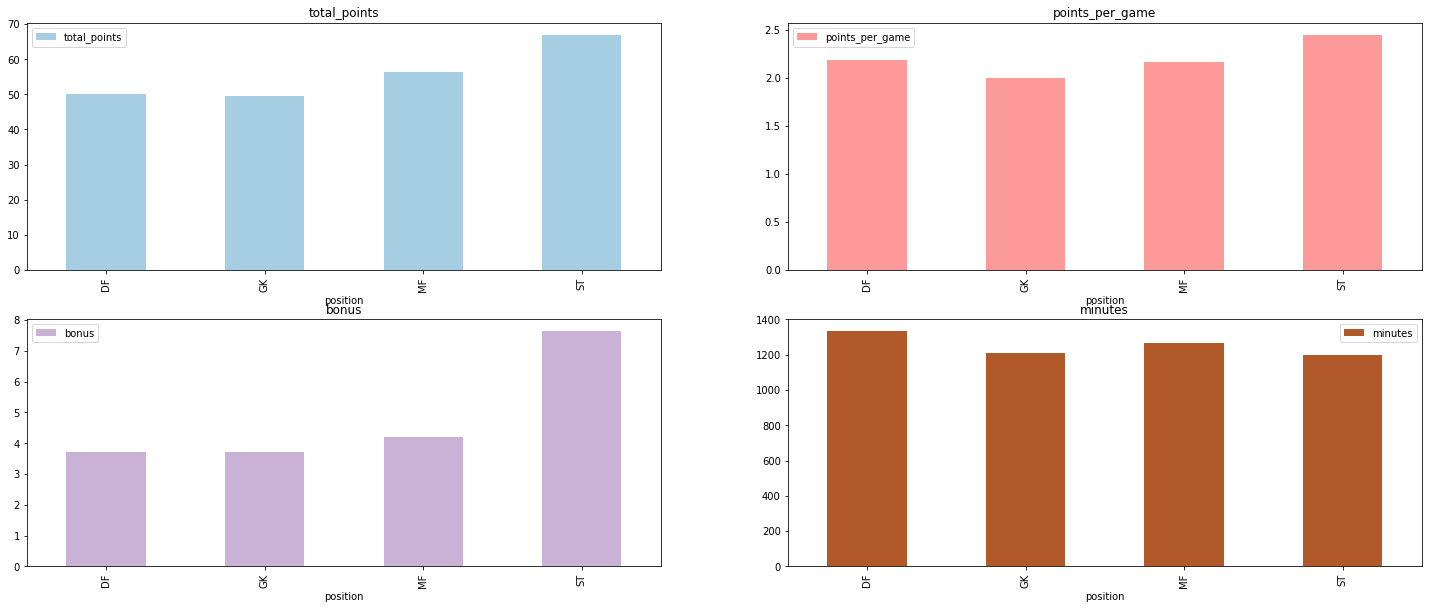

5:61: E703 statement ends with a semicolon


In [1055]:
full_data.loc[:, ['total_points', 'points_per_game', 'bonus',
                  'position', 'minutes']]\
    .groupby(['position']).mean()\
    .plot.bar(colormap='Paired', layout=(2, 2),
              subplots=True, figsize=(25, 10), sharex=False);

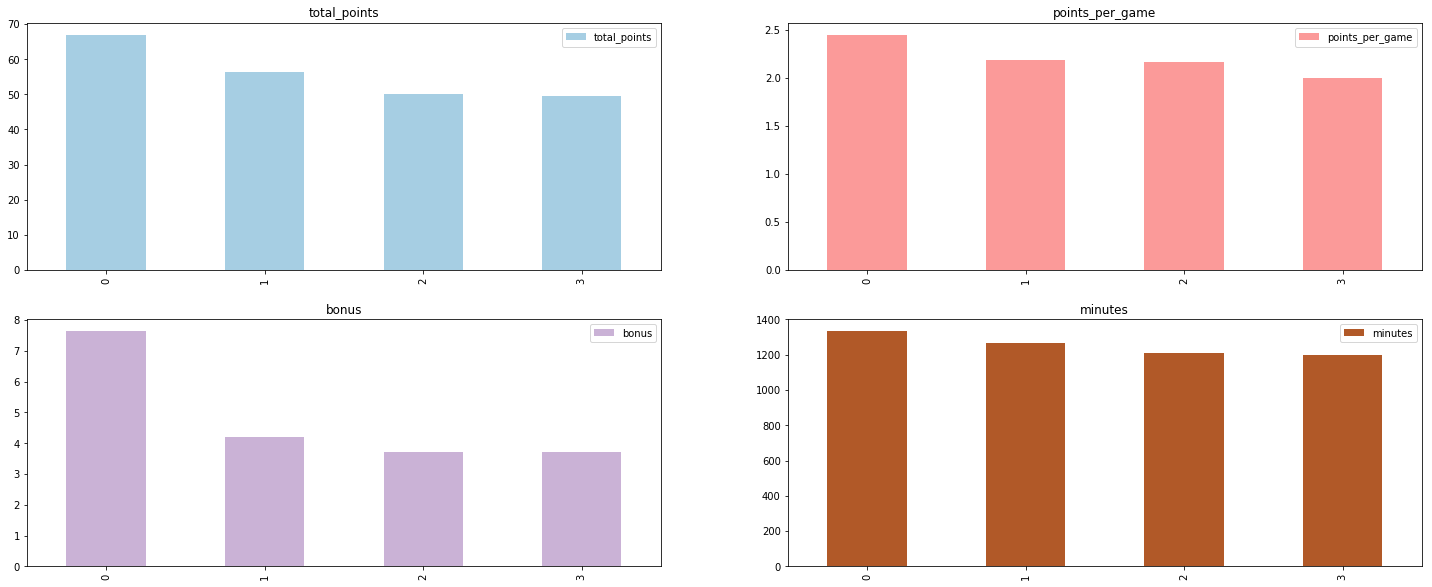

7:32: E231 missing whitespace after ','
7:49: E703 statement ends with a semicolon


In [1052]:
full_data.loc[:, ['total_points', 'points_per_game', 'bonus',
                  'position', 'minutes']]\
    .groupby(['position']).mean()\
    .apply(lambda x: x.sort_values(ascending=False).values)\
    .plot.bar(colormap='Paired', layout=(2, 2),
              subplots=True, figsize=(25, 10), sharex=False,
              sort_columns=True,use_index=False);

In [1056]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# set jupyter's max row display
pd.set_option('display.max_row', 1000)

# set jupyter's max column width to 50
pd.set_option('display.max_columns', 50)

In [1069]:
df = full_data.loc[:, ['total_points', 'points_per_game', 'bonus',
                  'position', 'minutes']]\
    .groupby(['position']).mean()
ax = full_data.loc[:, ['total_points', 'points_per_game', 'bonus',
                  'position', 'minutes']]\
    .groupby(['position']).mean()\
.plot(kind='barh', figsize=(10,7),
    colormap="Paired", fontsize=13);\
ax.set_alpha(0.8)
ax.set_title("Where were the battles fought?", fontsize=18)
ax.set_xlabel("Number of Battles", fontsize=18);
ax.set_xticks([0, 5, 10, 15, 20])

for idx, label in enumerate(list(df.index)): 
    for acc in df.columns:
        value = np.round(df.ix[idx][acc],decimals=2)
        ax.annotate(value,(idx, value),
                    xytext=(0, 15), 
                    textcoords='offset points')



ValueError: Image size of 618x126957 pixels is too large. It must be less than 2^16 in each direction.

<Figure size 720x504 with 1 Axes>

2:19: E128 continuation line under-indented for visual indent
5:19: E128 continuation line under-indented for visual indent
7:1: E122 continuation line missing indentation or outdented
7:31: E231 missing whitespace after ','
8:5: E128 continuation line under-indented for visual indent
8:36: E702 multiple statements on one line (semicolon)
9:1: E122 continuation line missing indentation or outdented
11:48: E703 statement ends with a semicolon
14:45: W291 trailing whitespace
16:41: E231 missing whitespace after ','
17:26: E231 missing whitespace after ','
18:36: W291 trailing whitespace
21:1: W391 blank line at end of file


In [1070]:
df.head(5)

,total_points,points_per_game,bonus,minutes
position,,,,
DF,50.045714,2.180571,3.708571,1333.228571
GK,49.620000,2.002000,3.700000,1207.560000
MF,56.480198,2.163861,4.188119,1267.009901
ST,67.000000,2.449180,7.639344,1198.639344


In [ ]:
# create a list to collect the plt.patches data
totals = []

# find the values and append to list
for i in ax.patches:
    totals.append(i.get_width())

# set individual bar lables using above list
total = sum(totals)

# set individual bar lables using above list
for i in ax.patches:
    # get_width pulls left or right; get_y pushes up or down
    ax.text(i.get_width()+.3, i.get_y()+.38, \
            str(round((i.get_width()/total)*100, 2))+'%', fontsize=15,
color='dimgrey')

# invert for largest on top 
ax.invert_yaxis()

### V. Largest Metrics for Players

1. Total Points
2. Minutes
3. Bonus

In [49]:
full_data.nlargest(15 , 'total_points')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points']]

,first_name,second_name,name,now_cost,total_points
274,Kevin,De Bruyne,Man City,115,251
256,Mohamed,Salah,Liverpool,120,233
253,Sadio,Mané,Liverpool,120,221
203,Jamie,Vardy,Leicester,100,210
261,Trent,Alexander-Arnold,Liverpool,75,210
3,Pierre-Emerick,Aubameyang,Arsenal,120,205
278,Raheem,Sterling,Man City,115,204
305,Anthony,Martial,Man Utd,90,200
374,Danny,Ings,Southampton,85,198
471,Raúl,Jiménez,Wolves,85,194


In [52]:
full_data.nlargest(15 , 'minutes')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'minutes']]

,first_name,second_name,name,now_cost,total_points,minutes
70,Mathew,Ryan,Brighton,45,135,3420
81,James,Tarkowski,Burnley,55,143,3420
96,Nick,Pope,Burnley,55,170,3420
158,Jordan,Pickford,Everton,50,117,3420
196,Kasper,Schmeichel,Leicester,55,156,3420
252,Virgil,van Dijk,Liverpool,65,178,3420
293,David,de Gea,Man Utd,55,143,3420
300,Harry,Maguire,Man Utd,55,123,3420
328,Martin,Dubravka,Newcastle,50,143,3420
357,George,Baldock,Sheffield Utd,55,142,3420


In [53]:
full_data.nlargest(15 , 'bonus')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'bonus']]

,first_name,second_name,name,now_cost,total_points,bonus
374,Danny,Ings,Southampton,85,198,40
3,Pierre-Emerick,Aubameyang,Arsenal,120,205,37
274,Kevin,De Bruyne,Man City,115,251,35
203,Jamie,Vardy,Leicester,100,210,34
471,Raúl,Jiménez,Wolves,85,194,33
308,Marcus,Rashford,Man Utd,95,177,31
253,Sadio,Mané,Liverpool,120,221,27
27,Willian,Borges Da Silva,Arsenal,80,168,26
256,Mohamed,Salah,Liverpool,120,233,26
397,Harry,Kane,Spurs,105,158,26


In [57]:
full_data.nlargest(15 , 'goals_scored')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'goals_scored']]

,first_name,second_name,name,now_cost,total_points,goals_scored
203,Jamie,Vardy,Leicester,100,210,23
3,Pierre-Emerick,Aubameyang,Arsenal,120,205,22
374,Danny,Ings,Southampton,85,198,22
278,Raheem,Sterling,Man City,115,204,20
256,Mohamed,Salah,Liverpool,120,233,19
253,Sadio,Mané,Liverpool,120,221,18
397,Harry,Kane,Spurs,105,158,18
305,Anthony,Martial,Man Utd,90,200,17
308,Marcus,Rashford,Man Utd,95,177,17
471,Raúl,Jiménez,Wolves,85,194,17


In [58]:
full_data.nlargest(15 , 'assists')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'assists']]

,first_name,second_name,name,now_cost,total_points,assists
274,Kevin,De Bruyne,Man City,115,251,23
261,Trent,Alexander-Arnold,Liverpool,75,210,15
277,Riyad,Mahrez,Man City,85,175,14
399,Heung-Min,Son,Spurs,90,169,13
257,Andrew,Robertson,Liverpool,70,181,12
214,Harvey,Barnes,Leicester,70,133,10
253,Sadio,Mané,Liverpool,120,221,10
256,Mohamed,Salah,Liverpool,120,233,10
27,Willian,Borges Da Silva,Arsenal,80,168,9
251,Roberto,Firmino,Liverpool,95,155,9


In [59]:
full_data.nlargest(15 , 'creativity')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'creativity']]

,first_name,second_name,name,now_cost,total_points,creativity
274,Kevin,De Bruyne,Man City,115,251,1990.8
261,Trent,Alexander-Arnold,Liverpool,75,210,1380.3
210,James,Maddison,Leicester,70,125,1246.4
37,Jack,Grealish,Aston Villa,70,149,1209.2
465,João Filipe Iria,Santos Moutinho,Wolves,55,113,1200.1
27,Willian,Borges Da Silva,Arsenal,80,168,1177.7
156,Lucas,Digne,Everton,60,120,1112.0
378,James,Ward-Prowse,Southampton,60,117,989.9
257,Andrew,Robertson,Liverpool,70,181,980.2
100,Dwight,McNeil,Burnley,60,123,931.4


In [60]:
full_data.nlargest(15 , 'yellow_cards')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'yellow_cards']]

,first_name,second_name,name,now_cost,total_points,yellow_cards
138,Luka,Milivojevic,Crystal Palace,60,81,12
8,Granit,Xhaka,Arsenal,55,73,10
81,James,Tarkowski,Burnley,55,143,10
105,Jorge Luiz,Frello Filho,Chelsea,50,92,10
472,Romain,Saïss,Wolves,50,103,10
62,Lewis,Dunk,Brighton,50,128,9
89,Ashley,Westwood,Burnley,55,118,9
131,James,McCarthy,Crystal Palace,45,41,9
165,Dominic,Calvert-Lewin,Everton,70,126,9
378,James,Ward-Prowse,Southampton,60,117,9


In [64]:
full_data.nlargest(15 , 'points_per_game')[['first_name'  , 'second_name', 'name' , 'now_cost' , 'total_points' , 'points_per_game']]

,first_name,second_name,name,now_cost,total_points,points_per_game
304,Bruno Miguel,Borges Fernandes,Man Utd,105,117,8.4
274,Kevin,De Bruyne,Man City,115,251,7.2
256,Mohamed,Salah,Liverpool,120,233,6.9
253,Sadio,Mané,Liverpool,120,221,6.3
278,Raheem,Sterling,Man City,115,204,6.2
305,Anthony,Martial,Man Utd,90,200,6.2
203,Jamie,Vardy,Leicester,100,210,6.0
3,Pierre-Emerick,Aubameyang,Arsenal,120,205,5.7
308,Marcus,Rashford,Man Utd,95,177,5.7
104,Marcos,Alonso,Chelsea,60,100,5.6


# Second Part of the Notebook : 

1. Get the 15 players that will optimize the FPL selection for the first round ( captain , bench)
2. Get a list of players in the pipe that potentially can be substituted
3. Get a feeling when to use advantages in FPL ( triple captain , bench boost , wildcard )
4. Model lives through time with parameters updated ( injuries, good run, 

### Algorithm 

* Pre-requisite : Create a coefficient based on several features that will determine player attractiveness
* Start with a number of points , and get the cost with limitations of 3 players per team ( team_code ) 
* Choose goalkeepers , defenders , midfielders , strikers ( 2 , 5 , 5 , 3 ) 


### Element Type : 

* element_type = 1,2,3,4 => GK,DF,MF,ST


#### 1. Constants

In [481]:
limit_gk = 2
limit_df = 5
limit_md = 5
limit_st = 3
star_player_limit = 3

In [483]:
FPL_data[FPL_data['web_name'] == 'Sterling']['points_per_game']

278    6.2
Name: points_per_game, dtype: float64

In [484]:
list_players

['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Lundstram',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Westwood',
 'Grealish',
 'Stephens']

In [502]:
sum(pd.Series(list_players).apply(lambda x : sum(FPL_data[FPL_data['web_name'] == x]['points_per_game'])))

70.2

In [497]:
list_players2 = ['Sterling',
 'Antonio',
 'Martial',
 'Fernandes',
 'Greenwood',
 'Trézéguet',
 'Adams',
 'Thomas',
 'Lloris',
 'Walker',
 'Rice',
 'Laporte',
 'Pieters',
 'Alderweireld',
 'McCarthy']

#### 2. Functions

In [517]:
def compare_two_teams(datadf, team1, team2, key):
    team1_value = sum(pd.Series(team1).apply(lambda x : sum(datadf[datadf['web_name'] == x][key])))
    team2_value = sum(pd.Series(team2).apply(lambda x : sum(datadf[datadf['web_name'] == x][key])))
    return (team2 if team2_value > team1_value else team1) , team2_value , team1_value

In [90]:
full_data.sort_values(by = 'points_per_game' , ascending = False)[['name' , 'first_name' , 'second_name' , 'points_per_game' , 'now_cost']].head(20)

,name,first_name,second_name,points_per_game,now_cost
304,Man Utd,Bruno Miguel,Borges Fernandes,8.4,105
274,Man City,Kevin,De Bruyne,7.2,115
256,Liverpool,Mohamed,Salah,6.9,120
253,Liverpool,Sadio,Mané,6.3,120
305,Man Utd,Anthony,Martial,6.2,90
278,Man City,Raheem,Sterling,6.2,115
203,Leicester,Jamie,Vardy,6.0,100
3,Arsenal,Pierre-Emerick,Aubameyang,5.7,120
308,Man Utd,Marcus,Rashford,5.7,95
104,Chelsea,Marcos,Alonso,5.6,60


### Create a return on Price

In [93]:
full_data['roi'] = full_data['points_per_game']/full_data['now_cost']
full_data['roi_total'] = full_data['total_points']/full_data['now_cost']

In [92]:
full_data.sort_values(by = 'roi' , ascending = False)[['name' , 'first_name' , 'second_name' , 'points_per_game' , 'now_cost' , 'roi' , 'minutes']].head(20)

,name,first_name,second_name,points_per_game,now_cost,roi,minutes
219,Leicester,Luke,Thomas,5.0,45,0.111111,267
440,West Ham,David,Martin,4.0,40,0.100000,435
104,Chelsea,Marcos,Alonso,5.6,60,0.093333,1429
9,Arsenal,Pablo,Marí,4.0,45,0.088889,113
329,Newcastle,Florian,Lejeune,4.0,45,0.088889,440
392,Spurs,Hugo,Lloris,4.7,55,0.085455,1808
82,Burnley,Phil,Bardsley,3.7,45,0.082222,1890
371,Southampton,Alex,McCarthy,3.7,45,0.082222,2520
11,Arsenal,Emiliano,Martínez,3.7,45,0.082222,770
324,Newcastle,Matt,Ritchie,4.1,50,0.082000,1312


In [95]:
full_data.sort_values(by = 'roi_total' , ascending = False)[['name' , 'first_name' , 'second_name' , 'points_per_game' , 'now_cost' , 'roi_total' , 'minutes' , 'element_type']].head(20)

,name,first_name,second_name,points_per_game,now_cost,roi_total,minutes,element_type
96,Burnley,Nick,Pope,4.5,55,3.090909,3420,1
70,Brighton,Mathew,Ryan,3.6,45,3.000000,3420,1
307,Man Utd,Dean,Henderson,4.4,55,2.909091,3240,1
328,Newcastle,Martin,Dubravka,3.8,50,2.860000,3420,1
196,Leicester,Kasper,Schmeichel,4.1,55,2.836364,3420,1
261,Liverpool,Trent,Alexander-Arnold,5.5,75,2.800000,3173,2
468,Wolves,Matt,Doherty,4.6,60,2.783333,2836,2
466,Wolves,Rui Pedro,dos Santos Patrício,4.0,55,2.781818,3420,1
128,Crystal Palace,Vicente,Guaita,3.9,50,2.740000,3150,1
252,Liverpool,Virgil,van Dijk,4.7,65,2.738462,3420,2


In [449]:
sorted_full_data = full_data.sort_values(by = 'roi_total' , ascending = False).reset_index()
#sorted_full_data = full_data.sort_values(by = 'roi_total' , ascending = False).reset_index()

In [103]:
list_players = []
total_price = 0
team_count = []
player_points = 0
i=0

while ((total_price < 1000)  & (i <sorted_full_data.shape[0])):
    #for i in tqdm(range(FPL_data.shape[0])):
   
    if i >= sorted_full_data.shape[0]:
        break
    if sorted_full_data.iloc[i].roi_total > player_points:
       player_points = sorted_full_data.iloc[i].points_per_game
       print(player_points)
       total_price += sorted_full_data.iloc[i]['now_cost']
       print(sorted_full_data.iloc[i]['now_cost']/10)
       print(sorted_full_data.iloc[i].web_name)
       
       team_count.append(sorted_full_data.iloc[i]['team_code'])
       print(team_count)
       if ( 4 in Counter(team_count).values()):
          i = i + 1
          del team_count[-1]
          total_price = total_price -  sorted_full_data.iloc[i]['now_cost']
          print(total_price)
          continue
       print(sorted_full_data.iloc[i].web_name)
       list_players.append(sorted_full_data.iloc[i].web_name)
       print(len(list_players))
              
    if (len(list_players) == 15):
        break
    i +=1
    #print(total_price)

4.5
5.5
Pope
[90]
Pope
1


In [120]:
FPL_data.columns

Index(['assists', 'bonus', 'bps', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'clean_sheets', 'code',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'creativity', 'dreamteam_count',
       'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name',
       'form', 'goals_conceded', 'goals_scored', 'ict_index', 'i_d',
       'in_dreamteam', 'influence', 'minutes', 'news', 'news_added',
       'now_cost', 'own_goals', 'penalties_missed', 'penalties_saved', 'photo',
       'points_per_game', 'red_cards', 'saves', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team',
       'team_code', 'threat', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'yellow_cards'],
      dtype='object')

In [121]:
FPL_data['in_dreamteam'].value_counts(dropna = False)

False    488
Name: in_dreamteam, dtype: int64

In [475]:
list_players = []
total_price = 0
team_count = []
player_points = 0
position = []
star_player = 0
i=0
cost_players = []

while ((total_price < 1000)  & (i <sorted_full_data.shape[0])):
    #for i in tqdm(range(FPL_data.shape[0])):
    if (position.count(1) < 2 ) & (sorted_full_data.element_type[i] == 1):
        position.append(sorted_full_data.element_type[i])
        list_players.append(sorted_full_data.iloc[i].web_name)
        total_price += sorted_full_data.now_cost[i]
        cost_players.append(sorted_full_data.now_cost[i])
        if (sorted_full_data.iloc[i].web_name in star_players):
            star_player +=1
    elif ((position.count(2) < 5 ) & (sorted_full_data.element_type[i] == 2) & (sorted_full_data.iloc[i].web_name not in star_players)):
        position.append(sorted_full_data.element_type[i])
        list_players.append(sorted_full_data.iloc[i].web_name)
        total_price += sorted_full_data.now_cost[i]
        cost_players.append(sorted_full_data.now_cost[i])
        #if (sorted_full_data.iloc[i].web_name in star_players):
            #star_player +=1
    elif (position.count(3) < 5 ) & (sorted_full_data.element_type[i] == 3):
        position.append(sorted_full_data.element_type[i])
        list_players.append(sorted_full_data.iloc[i].web_name)
        total_price += sorted_full_data.now_cost[i]
        cost_players.append(sorted_full_data.now_cost[i])
        if (sorted_full_data.iloc[i].web_name in star_players):
            star_player +=1
    elif (position.count(4) < 3 ) & (sorted_full_data.element_type[i] == 4):
        position.append(sorted_full_data.element_type[i])
        list_players.append(sorted_full_data.iloc[i].web_name)
        total_price += sorted_full_data.now_cost[i]
        cost_players.append(sorted_full_data.now_cost[i])
        if (sorted_full_data.iloc[i].web_name in star_players):
            star_player +=1
    #total_price += sorted_full_data.now_cost[i]
    #print(total_price)
    #if (sorted_full_data.iloc[i].web_name in star_players):
        #star_player +=1
    #print(list_players)
    if (star_player > 5 ):
        del list_players[-1]
        del position[-1]
        del cost_players[-1]
        total_price = total_price - sorted_full_data.now_cost[i]
        star_player = star_player - 1
        
        
    if total_price > 1000:
        del list_players[-1]
        del position[-1]
        del cost_players[-1]
        total_price = total_price - sorted_full_data.now_cost[i]
    elif len(list_players) == 15:
        break
    elif ((len(list_players) < 15 ) & (i == sorted_full_data.shape[0] -1)):
        del list_players[-1]
        del position[-1]
        del cost_players[-1]
        total_price = total_price - sorted_full_data.now_cost[i]
        i = 0
        
    i = i + 1
    


In [476]:
len(list_players)

15

In [477]:
cost_players

[55, 45, 60, 65, 50, 55, 55, 70, 85, 85, 90, 115, 55, 70, 45]

In [478]:
total_price

1000

In [479]:
star_player

5

In [480]:
list_players

['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Lundstram',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Westwood',
 'Grealish',
 'Stephens']

### Enhance algorithm with including : 

* Dream Team Player in each line ( MF , DF , ST)
* Minutes factor
* Form Factor 
* Assists for Forwards 
* Goals for Midfield
* Specific Players in Input ( not really AI )

* Remove Lundstram as defender then midfielder
* Add constraint of team 
* Limit the players to maximum 4 players from city and United

In [525]:
sorted_full_data.short_name.value_counts(dropna = False)

MUN    31
ARS    28
BHA    28
NEW    27
WHU    26
LIV    25
AVL    25
LEI    25
TOT    25
CRY    24
WOL    24
CHE    24
SOU    23
LEE    23
EVE    23
FUL    23
MCI    23
WBA    21
BUR    20
SHU    20
Name: short_name, dtype: int64

In [782]:
star_players = list(full_data_form.nlargest(7 , 'total_points')['web_name'])

In [783]:
list_players = []
total_price = 0
team_count = []
player_points = 0
position = []
star_player = 0
i=0
cost_players = []
manchester_factor = 0

while ((total_price < 1000)  & (i <sorted_full_data.shape[0])):
    #for i in tqdm(range(FPL_data.shape[0])):
    if (sorted_full_data.status[i]=='a'):
        if (sorted_full_data.iloc[i].web_name in list_players):
            i = i+1
            continue
        if (sorted_full_data.web_name[i]=='Lundstram'):
            i = i+1
            continue
        if (position.count(1) < 2 ) & (sorted_full_data.element_type[i] == 1):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
        elif ((position.count(2) < 5 ) & (sorted_full_data.element_type[i] == 2) & (sorted_full_data.iloc[i].web_name not in star_players)):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
            #if (sorted_full_data.iloc[i].web_name in star_players):
                #star_player +=1
        elif (position.count(3) < 5 ) & (sorted_full_data.element_type[i] == 3):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
        elif (position.count(4) < 3 ) & (sorted_full_data.element_type[i] == 4):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
        #total_price += sorted_full_data.now_cost[i]
        #print(total_price)
        #if (sorted_full_data.iloc[i].web_name in star_players):
            #star_player +=1
        #print(list_players)
        if (star_player > 5 ):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            star_player = star_player - 1

        if (manchester_factor > 4 ):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            manchester_factor = manchester_factor - 1


        if total_price > 1000:
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
        elif len(list_players) == 15:
            break
        elif ((len(list_players) < 15 ) & (i == sorted_full_data.shape[0] -1)):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            i = 0

        i = i + 1
    else:
        i = i+1
        continue


In [784]:
star_players

['De Bruyne',
 'Salah',
 'Mané',
 'Vardy',
 'Alexander-Arnold',
 'Aubameyang',
 'Sterling']

In [785]:
star_player

5

In [786]:
list_players

['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Henderson',
 'Willian',
 'Neves',
 'Trossard']

In [789]:
players_v2 = list_players

In [792]:
compare_two_teams(sorted_full_data,players_v2,players_new,'points_per_game')

(['Pope',
  'Ryan',
  'Doherty',
  'van Dijk',
  'Egan',
  'Tarkowski',
  'Robertson',
  'Ings',
  'Jiménez',
  'Martial',
  'De Bruyne',
  'Henderson',
  'Willian',
  'Neves',
  'Trossard'],
 70.30000000000001,
 72.60000000000001)

In [794]:
cost_players

[55, 45, 60, 65, 50, 55, 70, 85, 85, 90, 115, 55, 80, 55, 60]

In [795]:
list_players

['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Henderson',
 'Willian',
 'Neves',
 'Trossard']

In [788]:
len(list_players)

15

In [797]:
sum(cost_players)

1025

In [796]:
total_price

960

In [573]:
list_players_initial = ['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Lundstram',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Westwood',
 'Grealish',
 'Stephens']

In [745]:
players_new = ['Pope',
 'Ryan',
 'Doherty',
 'Egan',
 'Tarkowski',
 'Baldock',
 'Stevens',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Henderson',
 'Willian',
 'Rice',
 'Noble']

In [747]:
compare_two_teams(full_data,list_players_initial,players_new,'total_points')

(['Pope',
  'Ryan',
  'Doherty',
  'Egan',
  'Tarkowski',
  'Baldock',
  'Stevens',
  'Ings',
  'Jiménez',
  'Martial',
  'De Bruyne',
  'Henderson',
  'Willian',
  'Rice',
  'Noble'],
 2529,
 2509)

### Special Cases : 

* Lundstram is now a midfielder , martial striker , rashford Midfielder
* Minimum price of a midfielder = 4.5

### Get statistics of New Players

* Assists + goals + minutes played of new players
* Coefficient of power of bundesliga , french ligue etc ..


## Additionnal features in ROI 

* Players statistics against specific teams
* Get the form of a player and check the evolution over time

### Form : 

In [147]:
FPL_data_1920.form.describe()

count    666.000000
mean       1.252853
std        1.668514
min        0.000000
25%        0.000000
50%        0.400000
75%        2.100000
max       10.600000
Name: form, dtype: float64

In [150]:
FPL_data_1920.sample(n = 10)[['web_name' , 'first_name' , 'second_name' , 'form' , 'now_cost' , 'total_points']]

,web_name,first_name,second_name,form,now_cost,total_points
480,Henderson,Dean,Henderson,3.6,52,160
112,Ryan,Mathew,Ryan,3.7,47,135
357,Young,Ashley,Young,0.0,54,24
58,Konsa,Ezri,Konsa Ngoyo,4.2,43,65
341,Bernardo Silva,Bernardo Mota,Veiga de Carvalho e Silva,2.6,76,116
243,Bernard,Bernard,Anício Caldeira Duarte,1.1,64,72
191,Mount,Mason,Mount,3.1,60,137
274,Ward,Danny,Ward,0.0,42,0
302,Origi,Divock,Origi,1.9,51,65
593,João Pedro,João Pedro,Junqueira de Jesus,0.3,48,3


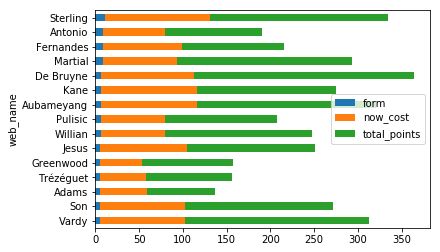

In [165]:
FPL_data_1920.reset_index().nlargest(15 , 'form')[['web_name' , 'first_name' , 'second_name' , 'form' , 'now_cost' , 'total_points']].sort_values(by='form').plot.barh(x='web_name',stacked=True);

In [167]:
FPL_data_1920.reset_index().nlargest(15 , 'form')[['web_name' , 'first_name' , 'second_name' , 'form' , 'now_cost' , 'total_points']].sort_values(by='form',ascending=False)

,web_name,first_name,second_name,form,now_cost,total_points
337,Sterling,Raheem,Sterling,10.6,120,204
609,Antonio,Michail,Antonio,9.0,71,111
372,Martial,Anthony,Martial,8.7,85,200
386,Fernandes,Bruno Miguel,Borges Fernandes,8.7,90,117
338,De Bruyne,Kevin,De Bruyne,7.1,106,251
10,Aubameyang,Pierre-Emerick,Aubameyang,6.7,109,205
536,Kane,Harry,Kane,6.7,110,158
177,Willian,Willian,Borges Da Silva,6.1,73,168
185,Pulisic,Christian,Pulisic,6.1,74,127
334,Jesus,Gabriel Fernando,de Jesus,6.0,99,146


In [307]:
full_data_form = pd.merge(full_data , FPL_data_1920[['first_name' , 'second_name' , 'form']] , on = ['first_name' , 'second_name'] , suffixes=('_2021','_1920'))

In [309]:
sorted_full_data = full_data_form.sort_values(by = 'form_1920' , ascending = False).reset_index()

In [371]:
sorted_full_data.columns

Index(['index', 'assists', 'bonus', 'bps', 'chance_of_playing_next_round',
       'chance_of_playing_this_round', 'clean_sheets', 'code_x',
       'cost_change_event', 'cost_change_event_fall', 'cost_change_start',
       'cost_change_start_fall', 'creativity', 'dreamteam_count',
       'element_type', 'ep_next', 'ep_this', 'event_points', 'first_name',
       'form_2021', 'goals_conceded', 'goals_scored', 'ict_index', 'i_d',
       'in_dreamteam', 'influence', 'minutes', 'news', 'news_added',
       'now_cost', 'own_goals', 'penalties_missed', 'penalties_saved', 'photo',
       'points_per_game', 'red_cards', 'saves', 'second_name',
       'selected_by_percent', 'special', 'squad_number', 'status', 'team',
       'team_code', 'threat', 'total_points', 'transfers_in',
       'transfers_in_event', 'transfers_out', 'transfers_out_event',
       'value_form', 'value_season', 'web_name', 'yellow_cards', 'id',
       'code_y', 'name', 'strength', 'short_name', 'strength_overall_home',
     

In [375]:
sorted_full_data.chance_of_playing_next_round.value_counts()

0.0      29
50.0      3
100.0     2
Name: chance_of_playing_next_round, dtype: int64

In [377]:
sorted_full_data[sorted_full_data.chance_of_playing_next_round.notna()]['web_name']

7          Pulisic
55           Jonny
119    Chamberlain
186          Evans
206        Mustafi
213    van Aanholt
230        Kovacic
255          Sakho
275        Gilmour
277      Lascelles
281          Skipp
282          Fuchs
290         Cahill
300    Gibbs-White
305          Schär
306       Chilwell
313          Ajeti
314          Watts
319           Hart
341        Tomkins
347           Cork
348         Clarke
350         Heaton
352           Marí
353       Chambers
356     Martinelli
361         Wesley
364        Montoya
365          Tosun
366         Gbamin
370          Chong
390          Bravo
397        Amartey
398        Pereira
Name: web_name, dtype: object

In [470]:
star_players = list(full_data_form.nlargest(10 , 'total_points')['web_name'])

In [471]:
star_players

['De Bruyne',
 'Salah',
 'Mané',
 'Vardy',
 'Alexander-Arnold',
 'Aubameyang',
 'Sterling',
 'Martial',
 'Ings',
 'Jiménez']

In [438]:
list_players = []
total_price = 0
team_count = []
player_points = 0
position = []
star_player = 0
i=0
cost_players = []

while ( (total_price < 1000) & (i <sorted_full_data.shape[0]) & (len(list_players) <15) ):
    #print(i)
    if (sorted_full_data.status[i]=='a'):
        if (sorted_full_data.iloc[i].web_name in list_players):
            continue
        #for i in tqdm(range(FPL_data.shape[0])):
        if (position.count(1) < 2 ) & (sorted_full_data.element_type[i] == 1) & (sorted_full_data.iloc[i].web_name not in list_players):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
        elif ((position.count(2) < 5 ) & (sorted_full_data.element_type[i] == 2) & (sorted_full_data.iloc[i].web_name not in list_players)& (sorted_full_data.iloc[i].web_name not in star_players)):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            #if (sorted_full_data.iloc[i].web_name in star_players):
                #star_player +=1
        elif (position.count(3) < 5 ) & (sorted_full_data.element_type[i] == 3) & (sorted_full_data.iloc[i].web_name not in list_players):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
        elif (position.count(4) < 3 ) & (sorted_full_data.element_type[i] == 4) &(sorted_full_data.iloc[i].web_name not in list_players):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
        #total_price += sorted_full_data.now_cost[i]
        #print(total_price)
        #if (sorted_full_data.iloc[i].web_name in star_players):
            #star_player +=1
        #print(list_players)
        if (star_player > 2 ):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            star_player = star_player - 1


        if (total_price > 1000):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            continue
        elif len(list_players) == 15:
            break
        elif ((len(list_players) < 15 ) & (i == sorted_full_data.shape[0] -1)):
            print(list_players[-1])
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            i = (len(list_players) +1)
            #print(i)
            i = i + 1
            continue
        i = i+1
    else:
        i = i + 1
    print(list_players)
    print(i)
    #print(i)
    #print(list_players)
    

['Sterling']
1
['Sterling', 'Antonio']
2
['Sterling', 'Antonio', 'Martial']
3
['Sterling', 'Antonio', 'Martial', 'Fernandes']
4
['Sterling', 'Antonio', 'Martial', 'Fernandes']
5
['Sterling', 'Antonio', 'Martial', 'Fernandes']
6
['Sterling', 'Antonio', 'Martial', 'Fernandes']
7
['Sterling', 'Antonio', 'Martial', 'Fernandes']
8
['Sterling', 'Antonio', 'Martial', 'Fernandes']
9
['Sterling', 'Antonio', 'Martial', 'Fernandes']
10
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood']
11
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood', 'Trézéguet']
12
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood', 'Trézéguet', 'Adams']
13
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood', 'Trézéguet', 'Adams']
14
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood', 'Trézéguet', 'Adams']
15
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood', 'Trézéguet', 'Adams']
16
['Sterling', 'Antonio', 'Martial', 'Fernandes', 'Greenwood', 'Trézéguet', 'Adams']
17


In [439]:
len(list_players)

15

In [440]:
star_player

2

In [442]:
star_players

['De Bruyne',
 'Salah',
 'Mané',
 'Vardy',
 'Alexander-Arnold',
 'Aubameyang',
 'Sterling',
 'Martial',
 'Ings',
 'Jiménez',
 'Robertson',
 'van Dijk',
 'Rashford',
 'Mahrez',
 'Pope',
 'Son',
 'Willian',
 'Doherty',
 'Richarlison',
 'Henderson',
 'Kane',
 'Schmeichel',
 'Firmino',
 'Abraham',
 'Patrício',
 'Grealish',
 'Jesus',
 'Lundstram',
 'Tarkowski',
 'de Gea',
 'Dubravka',
 'Stevens',
 'Baldock',
 'Mount',
 'Guaita',
 'Wood',
 'Ryan',
 'Barnes',
 'Ederson',
 'Egan',
 'Ayew',
 'Agüero',
 'Maupay',
 'Azpilicueta',
 'Traoré',
 'Pérez',
 'Dunk',
 'Evans',
 'Pulisic',
 'Wan-Bissaka']

In [441]:
list_players

['Sterling',
 'Antonio',
 'Martial',
 'Fernandes',
 'Greenwood',
 'Trézéguet',
 'Adams',
 'Thomas',
 'Lloris',
 'Walker',
 'Rice',
 'Laporte',
 'Pieters',
 'Alderweireld',
 'McCarthy']

In [433]:
position

[3, 4, 4, 3, 3, 3, 4, 2, 1, 2, 3, 2, 2, 2, 1]

In [434]:
cost_players

[115, 65, 90, 105, 75, 55, 60, 45, 55, 60, 50, 60, 45, 55, 45]

In [435]:
total_price

980

In [379]:
i

287

In [384]:
FPL_data_1920.status.value_counts(dropna = False)

a    475
u     65
n     60
i     52
d     11
s      3
Name: status, dtype: int64

In [385]:
FPL_data.status.value_counts(dropna = False)

a    453
i     21
n      6
d      3
u      3
s      2
Name: status, dtype: int64

In [389]:
FPL_data[FPL_data.status == 's']

,assists,bonus,bps,chance_of_playing_next_round,chance_of_playing_this_round,clean_sheets,code,cost_change_event,cost_change_event_fall,cost_change_start,...,threat,total_points,transfers_in,transfers_in_event,transfers_out,transfers_out_event,value_form,value_season,web_name,yellow_cards
107,3,6,461,0.0,NaN,4,91651,0,0,0,...,186.0,68,0,0,0,0,0.0,12.4,Kovacic,8
198,2,12,707,0.0,NaN,13,37642,0,0,0,...,325.0,128,0,0,0,0,0.0,23.3,Evans,7


## Maximize the 11 players that will be on field : 

1. GK top 5 ROI and lower cost 
2. Bench cost lowest with better ROI  ( 1 MF , 2DF , 1 GK )
3. 1 GK , 3 DF , 4MF , 3 ST as a formation 
4. 1 Star Player in each line minimum ( max of total points )

In [748]:
def team_price(datadf,team):
    return sum(pd.Series(team).apply(lambda x : sum(datadf[datadf['web_name'] == x]['now_cost'])))
    

In [690]:
def team_positions(datadf,team):
    return pd.Series(team).apply(lambda x : datadf[datadf['web_name'] == x]['element_type'])
    

In [616]:
def best_roi_minprice(position):
    """function that will return what is the best player by ROI based on a position on the field"""
    # Slice the dataframe based on the position
    sliced_data = sorted_full_data[sorted_full_data['element_type'] == position].reset_index(drop = True)
    # Get the minimum price of the list of players
    min_value = sliced_data.iloc[sliced_data['now_cost'].idxmin()]['now_cost']
    # Slice again the data according to the min_value 
    sliced_data = sliced_data[sliced_data['now_cost'] == min_value].reset_index()
    # Get the player with the maximum value for ROI 
    return sliced_data.iloc[sliced_data['roi_total'].idxmax()][['web_name' , 'now_cost' ,'minutes' ,'total_points']] 

In [639]:
def best_roi_price(position, pricevalue):
    """function that will return what is the best player by ROI based on a position on the field"""
    # Slice the dataframe based on the position
    sliced_data = sorted_full_data[sorted_full_data['element_type'] == position].reset_index(drop = True)
    # Get the minimum price of the list of players
    #min_value = sliced_data.iloc[sliced_data['now_cost'].idxmin()]['now_cost']
    # Slice again the data according to the min_value 
    sliced_data = sliced_data[sliced_data['now_cost'] == pricevalue].reset_index(drop=True)
    
    # Get the player with the maximum value for ROI 
    return sliced_data.iloc[sliced_data['roi_total'].idxmax()][['web_name' , 'now_cost' ,'minutes' ,'total_points']] 

In [642]:
def nlargest_roi(position, pricevalue, numofplayers):
    sliced_data = sorted_full_data[sorted_full_data['element_type'] == position].reset_index(drop = True)
    # Get the minimum price of the list of players
    #min_value = sliced_data.iloc[sliced_data['now_cost'].idxmin()]['now_cost']
    # Slice again the data according to the min_value 
    sliced_data = sliced_data[sliced_data['now_cost'] == pricevalue].reset_index(drop=True)
    return sliced_data.nlargest(numofplayers,'roi_total')[['web_name' , 'now_cost' ,'minutes' ,'total_points']]

In [662]:
nlargest_roi(1 , 45 , 1)

,web_name,now_cost,minutes,total_points
0,Ryan,45,3420,135


In [648]:
nlargest_roi(2 , 50 , 2)

,web_name,now_cost,minutes,total_points
0,Egan,50,3187,133
1,Dunk,50,3230,128


In [653]:
nlargest_roi(3 , 50 , 1)

,web_name,now_cost,minutes,total_points
0,Rice,50,3420,105


In [678]:
bench_players = ['Ryan' ,'Egan' ,'Dunk' ,'Rice']

In [668]:
star_players = list(full_data_form.nlargest(3 , 'total_points')['web_name'])

In [669]:
star_players

['De Bruyne', 'Salah', 'Mané']

In [677]:
star_players = list(full_data_form.nlargest(3 , 'points_per_game')['web_name'])

In [671]:
star_players

['Fernandes', 'De Bruyne', 'Salah']

In [675]:
star_players.append(bench_players)

In [683]:
1000 - team_price(sorted_full_data,star_players+bench_players)

415

In [689]:
sorted_full_data.element_type.value_counts(dropna = False)

3    202
2    175
4     61
1     50
Name: element_type, dtype: int64

In [691]:
team_positions(sorted_full_data,star_players+bench_players)

,1,10,17,37,44,69,197,358
0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0
1,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN
3,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN


In [713]:
len(star_players+bench_players)

7

In [732]:
initial_players = star_players+bench_players

In [763]:
initial_players

['Fernandes', 'De Bruyne', 'Salah', 'Ryan', 'Egan', 'Dunk', 'Rice']

In [733]:
star_players = list(full_data_form.nlargest(20 , 'total_points')['web_name'])

In [734]:
list_players = []
total_price = 0
team_count = []
player_points = 0
position = []
star_player = 0
i=0
cost_players = []
manchester_factor = 0

while ((total_price < 415)  & (i <sorted_full_data.shape[0])):
    #for i in tqdm(range(FPL_data.shape[0])):
    if (sorted_full_data.status[i]=='a'):
        if (sorted_full_data.iloc[i].web_name in list_players):
            i = i+1
            continue
        if (sorted_full_data.web_name[i]=='Lundstram' or sorted_full_data.web_name[i]=='Egan' 
            or sorted_full_data.web_name[i]=='Rice' or sorted_full_data.web_name[i]=='Ryan' 
              or sorted_full_data.web_name[i]=='van Dijk' or sorted_full_data.web_name[i]=='Henderson'
             or sorted_full_data.web_name[i]=='Robertson'):
            i = i+1
            continue
        if (position.count(1) < 1 ) & (sorted_full_data.element_type[i] == 1):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
        elif ((position.count(2) < 3 ) & (sorted_full_data.element_type[i] == 2) & (sorted_full_data.iloc[i].web_name not in star_players)):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
            #if (sorted_full_data.iloc[i].web_name in star_players):
                #star_player +=1
        elif (position.count(3) < 1 ) & (sorted_full_data.element_type[i] == 3):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
        elif (position.count(4) < 3 ) & (sorted_full_data.element_type[i] == 4):
            position.append(sorted_full_data.element_type[i])
            list_players.append(sorted_full_data.iloc[i].web_name)
            total_price += sorted_full_data.now_cost[i]
            cost_players.append(sorted_full_data.now_cost[i])
            if (sorted_full_data.iloc[i].web_name in star_players):
                star_player +=1
            if ((sorted_full_data.iloc[i].short_name == 'MUN') or (sorted_full_data.iloc[i].short_name == 'MCI')
               or (sorted_full_data.iloc[i].short_name == 'AVL') or (sorted_full_data.iloc[i].short_name == 'BUR')):
                manchester_factor += 1
        #total_price += sorted_full_data.now_cost[i]
        #print(total_price)
        #if (sorted_full_data.iloc[i].web_name in star_players):
            #star_player +=1
        #print(list_players)
        if (star_player > 0 ):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            star_player = star_player - 1

        if (manchester_factor > 1 ):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            manchester_factor = manchester_factor - 1


        if total_price > 415:
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
        elif len(list_players) == 8:
            break
        elif ((len(list_players) < 8 ) & (i == sorted_full_data.shape[0] -1)):
            del list_players[-1]
            del position[-1]
            del cost_players[-1]
            total_price = total_price - sorted_full_data.now_cost[i]
            i = 0
            continue

        i = i + 1
    else:
        i = i+1
        continue

    

In [735]:
len(list_players)

8

In [736]:
list_players

['Dubravka',
 'Baldock',
 'Stevens',
 "O'Connell",
 'Noble',
 'Abraham',
 'Maupay',
 'Calvert-Lewin']

In [738]:
new_list_players = list_players + initial_players

In [656]:
list_players_initial

['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Lundstram',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Westwood',
 'Grealish',
 'Stephens']

In [744]:
compare_two_teams(sorted_full_data,list_players_initial,new_list_players , 'points_per_game')

(['Pope',
  'Ryan',
  'Doherty',
  'van Dijk',
  'Egan',
  'Lundstram',
  'Tarkowski',
  'Robertson',
  'Ings',
  'Jiménez',
  'Martial',
  'De Bruyne',
  'Westwood',
  'Grealish',
  'Stephens'],
 66.50000000000001,
 70.2)

In [661]:
total_price

785

### Change the ROI 

* Include the Minutes factor
* Include Age ?
* Include if captain 
* Include if set piece taker 
* Include the form 

In [749]:
initial_players

['Fernandes', 'De Bruyne', 'Salah', 'Ryan', 'Egan', 'Dunk', 'Rice']

In [750]:
list_players

['Dubravka',
 'Baldock',
 'Stevens',
 "O'Connell",
 'Noble',
 'Abraham',
 'Maupay',
 'Calvert-Lewin']

In [751]:
new_list_players

['Dubravka',
 'Baldock',
 'Stevens',
 "O'Connell",
 'Noble',
 'Abraham',
 'Maupay',
 'Calvert-Lewin',
 'Fernandes',
 'De Bruyne',
 'Salah',
 'Ryan',
 'Egan',
 'Dunk',
 'Rice']

In [752]:
bench_players

['Ryan', 'Egan', 'Dunk', 'Rice']

In [756]:
starting_eleven_new = ['Dubravka',
 'Baldock',
 'Stevens',
 "O'Connell",
 'Noble',
 'Abraham',
 'Maupay',
 'Calvert-Lewin',
 'Fernandes',
 'De Bruyne',
 'Salah']

In [758]:
list_players_initial

['Pope',
 'Ryan',
 'Doherty',
 'van Dijk',
 'Egan',
 'Lundstram',
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 'Westwood',
 'Grealish',
 'Stephens']

In [759]:
starting_eleven_initial = ['Pope',
 
 'Doherty',
 'van Dijk',
 'Egan',
 
 'Tarkowski',
 'Robertson',
 'Ings',
 'Jiménez',
 'Martial',
 'De Bruyne',
 
 'Grealish'
 ]

In [761]:
compare_two_teams(sorted_full_data,starting_eleven_initial,starting_eleven_new,'total_points')

(['Pope',
  'Doherty',
  'van Dijk',
  'Egan',
  'Tarkowski',
  'Robertson',
  'Ings',
  'Jiménez',
  'Martial',
  'De Bruyne',
  'Grealish'],
 1661,
 1964)

In [798]:
compare_two_teams(sorted_full_data,starting_eleven_initial,starting_eleven_new,'points_per_game')

(['Pope',
  'Doherty',
  'van Dijk',
  'Egan',
  'Tarkowski',
  'Robertson',
  'Ings',
  'Jiménez',
  'Martial',
  'De Bruyne',
  'Grealish'],
 52.800000000000004,
 54.10000000000001)